   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset Shape: (20640, 9)

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


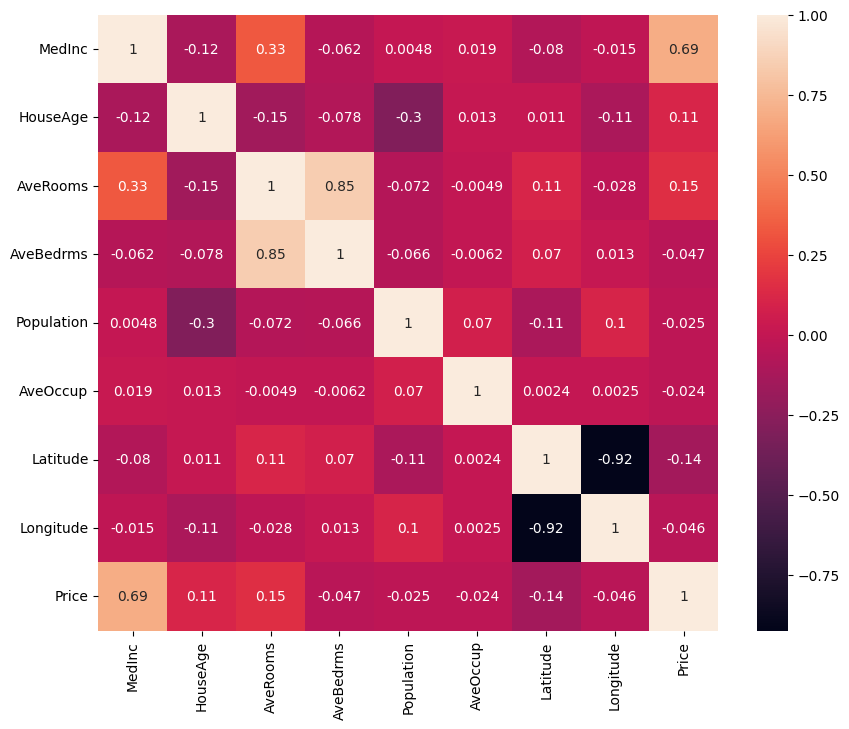


MAE = 0.5332001304956553
RMSE = 0.7455813830127764
R2 Score = 0.5757877060324508


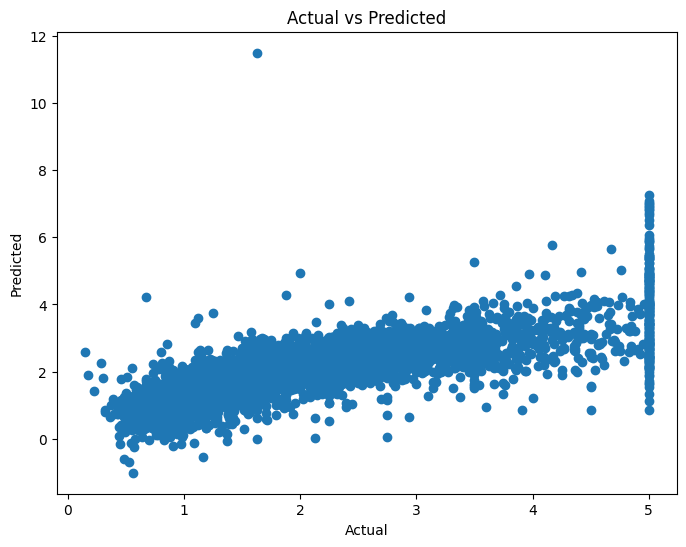


Task Completed Successfully


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

# Show first rows
print(df.head())

# Dataset information
print("\nDataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

# Features and Target
X = df.drop("Price", axis=1)
y = df["Price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
predictions = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("\nMAE =", mae)
print("RMSE =", rmse)
print("R2 Score =", r2)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")
plt.show()

print("\nTask Completed Successfully")